In [3]:
import os

from life_saving_scripts.basic_utils import set_publish_matplotlib_template
from manim_utils import get_colors
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

set_publish_matplotlib_template(mode="light")

/home/hari/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from manim import *

config.media_embed = True
BACKGROUND_COLOR, PRIMARY_COLOR, PRIMARY_COLORS = get_colors(dark_mode=True)
config.background_color = BACKGROUND_COLOR

In [5]:
IMAGE_DIR = "images"

In [6]:
from sklearn.datasets import make_classification, make_blobs

In [7]:
# X, y = make_classification(random_state=42, n_samples=100, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, n_classes=3)

# fig, ax = plt.subplots()
# ax.scatter(X[y == 0, 0], X[y == 0, 1], c="blue", label="Class 0")
# ax.scatter(X[y == 1, 0], X[y == 1, 1], c="red", label="Class 1")
# ax.scatter(X[y == 2, 0], X[y == 2, 1], c="green", label="Class 2")
# ax.set_xlabel("Feature 1")
# ax.set_ylabel("Feature 2")
# ax.legend()

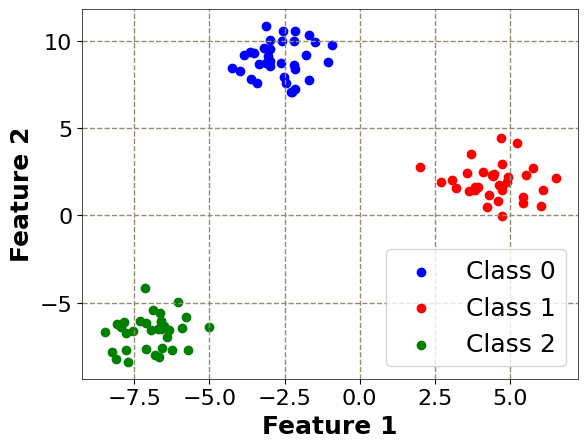

In [8]:
X, y = make_blobs(random_state=42, n_samples=100, n_features=2, centers=3, cluster_std=1)

fig, ax = plt.subplots()
ax.scatter(X[y == 0, 0], X[y == 0, 1], c="blue", label="Class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="red", label="Class 1")
ax.scatter(X[y == 2, 0], X[y == 2, 1], c="green", label="Class 2")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()

In [9]:
X[:, 0].min()*1.1, X[:, 0].max()*1.1

(np.float64(-9.335821468283749), np.float64(7.178671211182496))

In [18]:
points = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
points["y"] = y

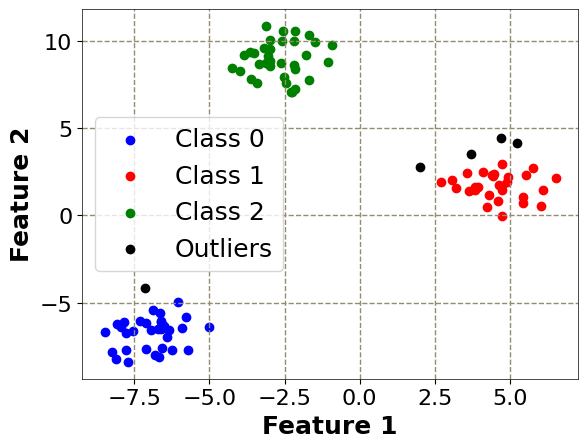

In [19]:
from sklearn.cluster import DBSCAN as SklearnDBSCAN

dbscan = SklearnDBSCAN(eps=1, min_samples=5)
y = dbscan.fit_predict(points[["Feature 1", "Feature 2"]])
fig, ax = plt.subplots()
X = points[["Feature 1", "Feature 2"]].values
ax.scatter(X[y == 0, 0], X[y == 0, 1], c="blue", label="Class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="red", label="Class 1")
ax.scatter(X[y == 2, 0], X[y == 2, 1], c="green", label="Class 2")
ax.scatter(X[y == -1, 0], X[y == -1, 1], c="black", label="Outliers")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()

In [20]:
class DBSCAN:

    def __init__(self, eps=1, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples

    def find_points_within_distance(
        self, idx, X: pd.DataFrame, distance_matrix: np.ndarray
    ):
        distance_array = distance_matrix[idx]
        mask = distance_array < self.eps
        df = X[mask]
        # remove the self point
        return df[df.index != idx]

    def create_distance_matrix(self, X: pd.DataFrame):
        distance_matrix = np.zeros((len(X), len(X)))
        for i in range(len(X)):
            for j in range(len(X)):
                distance_matrix[i, j] = np.linalg.norm(X.iloc[i] - X.iloc[j])
        return distance_matrix

    def classify_point_type(self, X: pd.DataFrame, distance_matrix: np.ndarray):
        core_points = []
        for i in range(X.shape[0]):
            if (
                len(self.find_points_within_distance(i, X, distance_matrix))
                >= self.min_samples
            ):
                core_points.append(i)

        border_points = []
        for i in range(X.shape[0]):
            if i not in core_points:
                if len(self.find_points_within_distance(i, X, distance_matrix)) > 0:
                    border_points.append(i)

        X["point_type"] = "outlier"
        X.loc[core_points, "point_type"] = "core"
        X.loc[border_points, "point_type"] = "border"
        return X

    def expand_cluster(self, idx, X, cluster, points_seen_till_now, distance_matrix):
        if idx in points_seen_till_now:
            return cluster

        points_seen_till_now.add(idx)
        cluster.append(idx)
        neighbors = self.find_points_within_distance(idx, X, distance_matrix)
        for neighbor in neighbors.index:
            self.expand_cluster(
                neighbor, X, cluster, points_seen_till_now, distance_matrix
            )
        return cluster

    def fit(self, X: pd.DataFrame):
        distance_matrix = self.create_distance_matrix(X)
        X = self.classify_point_type(X, distance_matrix)
        clusters = []
        points_seen_till_now = set()

        for i in range(X.shape[0]):

            if i in points_seen_till_now:
                continue
            if X.loc[i, "point_type"] == "outlier":
                continue

            neighbors = self.find_points_within_distance(i, X, distance_matrix)

            if len(neighbors) < self.min_samples:  # outliers
                X.loc[i, "point_type"] = "outlier"
                continue
            cluster = self.expand_cluster(
                i, X, [], points_seen_till_now, distance_matrix
            )
            clusters.append(cluster)

        for i, indices in enumerate(clusters):
            X.loc[indices, "cluster"] = i

        X["cluster"] = X["cluster"].fillna(-1)
        X["cluster"] = X["cluster"].astype(int)
        self.X = X
        self.distance_matrix = distance_matrix
        return X

In [21]:

dbscan = DBSCAN(eps=1, min_samples=5)
points = dbscan.fit(points)
points["cluster"].value_counts()

cluster
 1    34
 0    32
 2    29
-1     5
Name: count, dtype: int64

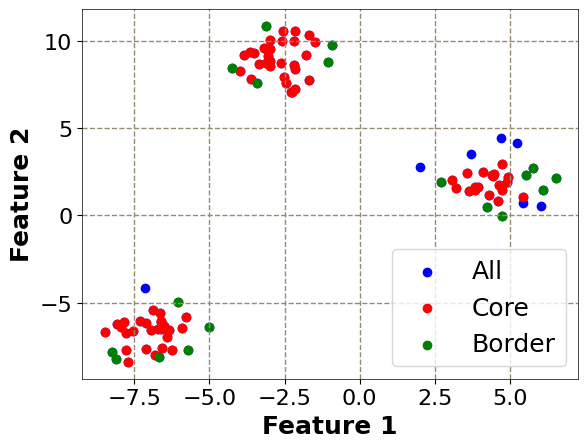

In [22]:
fig, ax = plt.subplots()
X = points[["Feature 1", "Feature 2"]].values
core_points_mask = points["point_type"] == "core"
border_points_mask = points["point_type"] == "border"
y = points["cluster"].values
ax.scatter(X[:, 0], X[:, 1], c="blue", label="All")
ax.scatter(X[core_points_mask, 0], X[core_points_mask, 1], c="red", label="Core")
ax.scatter(X[border_points_mask, 0], X[border_points_mask, 1], c="green", label="Border")
# ax.scatter(X[y == 2, 0], X[y == 2, 1], c="green", label="Class 2")
# ax.scatter(X[y == -1, 0], X[y == -1, 1], c="black", label="Outliers")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()

Text(0, 0.5, 'Feature 2')

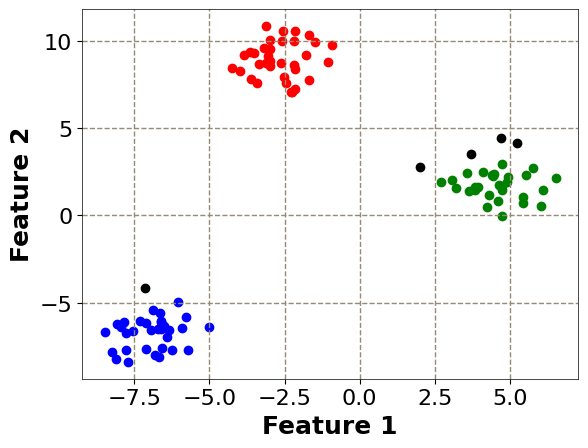

In [23]:
fig, ax = plt.subplots()
X = points[["Feature 1", "Feature 2"]].values
y = points["cluster"].values
ax.scatter(X[y == 0, 0], X[y == 0, 1], c="blue", label="Class 0")
ax.scatter(X[y == 1, 0], X[y == 1, 1], c="red", label="Class 1")
ax.scatter(X[y == 2, 0], X[y == 2, 1], c="green", label="Class 2")
ax.scatter(X[y == -1, 0], X[y == -1, 1], c="black", label="Outliers")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
# ax.legend()

In [24]:
TITLE_FONT_SIZE = 30
NORMAL_FONT_SIZE = 20
SMALL_FONT_SIZE = 15
TEXT_COLOR = TEAL
ARROW_COLOR = MAROON


class DBSCANViz(Scene):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.dbscan = dbscan
        self.df = self.dbscan.X
        self.X = self.dbscan.X[["Feature 1", "Feature 2"]].values
        self.y = self.dbscan.X["y"].values
        self.distance_matrix = self.dbscan.distance_matrix
        self.eps = self.dbscan.eps
        self.min_samples = self.dbscan.min_samples
        self.all_points = []
        self.core_point_idx = self.dbscan.X[
            self.dbscan.X["point_type"] == "core"
        ].index.tolist()
        self.border_point_idx = self.dbscan.X[
            self.dbscan.X["point_type"] == "border"
        ].index.tolist()
        self.outlier_point_idx = self.dbscan.X[
            self.dbscan.X["cluster"] == -1
        ].index.tolist()
        self.remaining_core_point_idx = self.core_point_idx.copy()
        self.remaining_border_point_idx = self.border_point_idx.copy()
        self.points_seen = set()
        self.outlier_color = GREY
        self.colors = [BLUE, RED, GREEN]
        self.quick_render = False

    def add_or_play(self, obj, create_func=None, duration=1):
        if not isinstance(obj, list):
            obj = [obj]
        if self.quick_render:
            if create_func == FadeOut:
                for o in obj:
                    self.remove(o)
            else:
                for o in obj:
                    self.add(o)
        else:
            self.play(*[create_func(o) for o in obj], duration=duration)

    def construct(self):
        title_text = Text("DBSCAN Clustering", font_size=30, color=TEXT_COLOR)
        title_text.to_edge(UP + LEFT)
        self.add(title_text)

        self.axes = Axes(
            x_range=[self.X[:, 0].min() * 1.1, self.X[:, 0].max() * 1.1],
            y_range=[self.X[:, 1].min() * 1.1, self.X[:, 1].max() * 1.1],
            axis_config={"color": PRIMARY_COLOR},
            x_length=8,
            y_length=8,
            tips=False,
        ).add_coordinates()
        self.add(self.axes)

        self.plot_datapoints(colors=[WHITE] * 3)

        point_idx = self.core_point_idx[0]
        current_cluster = self.df.loc[point_idx, "cluster"]
        cluster_change_counter = 0

        for i in tqdm(range(len(self.all_points))):

            if point_idx in self.points_seen or point_idx in self.outlier_point_idx:
                self.points_seen.add(point_idx)
                point_idx = self.get_nearest_point(point_idx)
                i += 1
                continue

            if len(self.points_seen) == len(self.all_points):
                break

            if i > len(self.core_point_idx) + len(self.border_point_idx):
                break
            cluster = self.df.loc[point_idx, "cluster"]
            if i == 0:
                self.one_iter(
                    point_idx,
                    text="Start with a random core point\nand find all points within eps",
                    extra_position=(2, 4),
                    add_arrow=True,
                )
            elif i == 1:
                self.one_iter(
                    point_idx,
                    text="Now, find the nearest point to the above core\npoint that is not seen yet and repeat",
                    extra_position=(2, 4),
                    add_arrow=True,
                )
            elif cluster != current_cluster:
                print(f"Cluster change from {current_cluster} to {cluster}")
                cluster_change_counter += 1
                cluster_change_name_map = {
                    0: "First",
                    1: "Second",
                    2: "Third",
                }
                self.one_iter(point_idx)
                text = self.create_text_near_a_point(
                    f"Wreached the end of cluster {current_cluster}\nand have found the {cluster_change_name_map[cluster_change_counter]} cluster",
                    at=point_idx,
                    extra_position=(6, -2) if cluster_change_counter == 1 else (3, 2),
                )
                self.add_or_play(text, Create, duration=1)
                self.wait(1)
                self.add_or_play(text, FadeOut, duration=0.5)
                current_cluster = cluster

            else:
                self.one_iter(point_idx)

            point_idx = self.get_nearest_point(point_idx)

        text = self.create_text_near_a_point(
            f"Remaining points are assigned to cluster -1\nand are considered as outliers",
            at=point_idx,
            extra_position=(2, 4),
        )
        self.add_or_play(text, Create, duration=1)
        self.wait(1)
        self.add_or_play(text, FadeOut, duration=0.5)
        self.color_outliers()
        # wait for a while
        self.wait(2)

    def one_iter(
        self,
        point_idx,
        text=None,
        extra_position=(0, 0),
        add_arrow=False,
        draw_text_first=True,
    ):
        mobjects_to_create = []
        if text is not None:
            text = self.create_text_near_a_point(
                text=text,
                at=point_idx,
                extra_position=extra_position,
            )
            mobjects_to_create.append(text)

        if add_arrow and text is not None:
            arrow = Arrow(
                text.get_center()+DOWN*0.15,
                self.all_points[point_idx].get_center(),
                buff=0.1,
                color=ARROW_COLOR,
            )
            mobjects_to_create.append(arrow)

        if len(mobjects_to_create) == 2:
            if not draw_text_first:
                mobjects_to_create = mobjects_to_create[::-1]

        for mobject in mobjects_to_create:
            self.add_or_play(mobject, Create, duration=1)

        self.create_circle_and_color_points(
            point_idx, color=self.find_color_for_cluster(point_idx)
        )
        point_idx = self.get_nearest_point(point_idx)

        if len(mobjects_to_create):
            self.add_or_play(mobjects_to_create, FadeOut, duration=0.5)

    def create_text_near_a_point(self, text, at, extra_position=(0, 0)):
        x, y = self.get_point_coord_from_index(at)
        x += extra_position[0]
        y += extra_position[1]
        position = self.axes.c2p(x, y)
        to = position
        text = Text(text, font_size=NORMAL_FONT_SIZE, color=TEXT_COLOR).move_to(to)
        return text

    def plot_datapoints(self, X=None, y=None, colors=None):
        X = X if X is not None else self.X
        y = y if y is not None else self.y
        colors = colors if colors is not None else self.colors
        classes = np.unique(self.y)

        for x_, y_ in zip(X[:, 0], X[:, 1]):
            dot = Dot(point=self.axes.c2p(x_, y_))
            self.all_points.append(dot)

        for c in classes:
            color = colors[c] if colors else WHITE
            mask = self.df["y"] == c
            indices = self.df[mask].index
            for idx in indices:
                dot = self.all_points[idx]
                dot.set_color(color)
                self.add(dot)

    def add_dot_and_circle(self, point, color=WHITE):
        x, y = point
        dot = Dot(point=self.axes.c2p(x, y), color=color)
        # radius of circle will not be eps, but will depend on the axes
        radius = (self.axes.c2p(0, self.eps) - self.axes.c2p(0, 0))[1]
        circle = Circle(radius=radius, color=color)
        circle.move_to(dot)
        vgroup = VGroup(dot, circle)
        return vgroup

    def get_point_coord_from_index(self, idx):
        return self.X[idx].tolist()

    def change_dot_color(self, dot, color):
        new_dot = dot.copy()
        new_dot.set_color(color)
        ReplacementTransform(dot, new_dot)
        return new_dot

    def color_all_points_within_a_circle(self, idx, color=WHITE):
        if idx in self.points_seen:
            return VGroup()
        self.points_seen.add(idx)
        self_dot = self.all_points[idx]
        self_dot = self.change_dot_color(self_dot, color)
        vgroup = VGroup(self_dot)

        points_within_distance = self.dbscan.find_points_within_distance(
            idx, self.dbscan.X, self.distance_matrix
        )
        for i in points_within_distance.index:
            if i in self.points_seen:
                continue
            self.points_seen.add(i)
            dot = self.all_points[i]
            dot = self.change_dot_color(dot, color)
            vgroup.add(dot)
        return vgroup

    def get_nearest_point(self, idx):
        distance_array = self.distance_matrix[idx].copy()

        # # take only core points
        # distance_array[
        #     self.df[self.df["point_type"] != "core"].index
        # ] = np.inf

        # remove the self point
        distance_array[idx] = np.inf
        min_idx = np.argmin(distance_array)

        i = 0
        while min_idx in self.points_seen:
            distance_array[min_idx] = np.inf
            min_idx = np.argmin(distance_array)
            i += 1
            if i > len(distance_array):
                break

        return min_idx

    def create_circle_and_color_points(self, idx, color=WHITE):
        g = self.add_dot_and_circle(self.get_point_coord_from_index(idx), color=color)
        self.add_or_play(g, Create, duration=0.1)
        _, circle = g
        points = self.color_all_points_within_a_circle(idx, color=color)
        self.add_or_play(points, Create, duration=0.1 * len(points))
        # remove the circle
        self.add_or_play(circle, FadeOut, duration=0.1)
        return g

    def find_color_for_cluster(self, idx):
        cluster = self.df.loc[idx, "cluster"].astype(int)
        if cluster == -1:
            return self.outlier_color
        return self.colors[cluster]

    def color_outliers(self):
        outlier_vgroup = VGroup()
        for idx in self.outlier_point_idx:
            dot = self.all_points[idx]
            dot = self.change_dot_color(dot, self.outlier_color)
            outlier_vgroup.add(dot)

        self.add_or_play(outlier_vgroup, Create, duration=0.5 * len(outlier_vgroup))

In [25]:
%%manim -qm -o dbscan_on_blobs.mp4 DBSCANViz
DBSCANViz

Manim Community v0.18.1

  8%|▊         | 8/100 [00:37<04:54,  3.20s/it]

Cluster change from 0 to 2


 19%|█▉        | 19/100 [01:13<02:58,  2.21s/it]

Cluster change from 2 to 1


100%|██████████| 100/100 [01:51<00:00,  1.11s/it]


In [52]:
dbscan.find_points_within_distance(5, dbscan.X, dbscan.distance_matrix)

,Feature 1,Feature 2,y,point_type,cluster
26,3.224508,1.552524,1,core,2
49,3.831385,1.471413,1,core,2
61,3.937826,1.645508,1,core,2
70,4.297164,1.170892,1,core,2
79,3.089215,2.041733,1,core,2
81,3.856626,1.651108,1,core,2


In [51]:
dbscan.X.iloc[5]

Feature 1     3.649343
Feature 2     1.406872
y                    1
point_type        core
cluster              2
Name: 5, dtype: object

In [10]:
class DBSCANViz(Scene):
    dbscan = dbscan
    X = dbscan.X[["Feature 1", "Feature 2"]].values
    y = y
    colors = [BLUE, RED, GREEN]
    eps = 1
    num_points = 5

    def construct(self):
        self.boundary_points = set()
        self.axes = Axes(
            x_range=[self.X[:, 0].min() * 1.1, self.X[:, 0].max() * 1.1],
            y_range=[self.X[:, 1].min() * 1.1, self.X[:, 1].max() * 1.1],
            axis_config={"color": PRIMARY_COLOR},
            x_length=8,
            y_length=8,
            tips=False,
        ).add_coordinates()
        self.add(self.axes)
        self.plot_datapoints()

        random_point_idx = np.random.randint(0, len(self.X))
        random_point = self.X[10]
        circle = self.add_dot_and_circle(random_point)
        self.play(Create(circle))
        g = self.color_all_points_within_a_circle(random_point)
        self.play(Create(g), run_time=3)

    def plot_datapoints(self, X=None, y=None, colors=None):
        X = X if X is not None else self.X
        y = y if y is not None else self.y
        colors = colors if colors is not None else self.colors
        classes = np.unique(self.y)
        for c in classes:
            color = colors[c] if colors else WHITE
            mask = self.y == c
            x = self.X[mask, 0]
            y = self.X[mask, 1]
            for x_, y_ in zip(x, y):
                dot = Dot(point=self.axes.c2p(x_, y_), color=color)
                self.add(dot)

    def add_dot_and_circle(self, point):
        x, y = point
        dot = Dot(point=self.axes.c2p(x, y), color=WHITE)
        # radius of circle will not be eps, but will depend on the axes
        radius = (self.axes.c2p(0, self.eps) - self.axes.c2p(0, 0))[1]
        circle = Circle(radius=radius, color=WHITE)
        circle.move_to(dot)
        vgroup = VGroup(dot, circle)
        return vgroup

    def color_all_points_within_a_circle(self, point, color=WHITE):
        new_points = self.get_all_points_within_a_circle(point)
        x, y = new_points[:, 0], new_points[:, 1]
        vgroup = VGroup()
        for x_, y_ in zip(x, y):
            dot = Dot(point=self.axes.c2p(x_, y_), color=color)
            vgroup.add(dot)
        return vgroup

    def get_all_points_within_a_circle(self, point):
        distance = np.linalg.norm(self.X - point, axis=1)
        mask = distance <= self.eps
        distance = distance[mask]
        distance_sorted = np.argsort(distance)
        points = self.X[mask]
        points = points[distance_sorted]
        x = points[:, 0]
        y = points[:, 1]
        b_ps = zip(x, y)
        self.boundary_points.update(b_ps)
        return points

In [11]:
%%manim -ql DBSCANViz
DBSCANViz

Manim Community v0.18.1